In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy

print("Environment setup successful!")
print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)

Environment setup successful!
Pandas: 3.0.3
NumPy: 2.4.6


In [2]:
import pandas as pd
import os
import glob

# Find CSV files inside the dataset folder
files = glob.glob("../dataset/*.csv")

print("Dataset files found:")
for file in files:
    print(file)

Dataset files found:
../dataset\seasonal_agriculture_performance_dataset.csv


In [3]:
# Load the agricultural dataset
file_path = files[0]

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully!
Rows: 4000
Columns: 28


In [4]:
df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [5]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn names:")
for i, column in enumerate(df.columns, start=1):
    print(i, "->", column)

Number of rows: 4000
Number of columns: 28

Column names:
1 -> Farm_ID
2 -> State
3 -> District
4 -> Crop
5 -> Season
6 -> Farm_Area_Hectares
7 -> Rainfall_mm
8 -> Avg_Temperature_C
9 -> Humidity_pct
10 -> Sunlight_Hours_Day
11 -> Soil_pH
12 -> Soil_Moisture_pct
13 -> Nitrogen_kg_ha
14 -> Phosphorus_kg_ha
15 -> Potassium_kg_ha
16 -> Irrigation_Method
17 -> Fertilizer_kg_ha
18 -> Pesticide_Litre_ha
19 -> Seed_Quality_Score
20 -> Yield_Tonnes_Ha
21 -> Production_Tonnes
22 -> Market_Price_INR_Tonne
23 -> Total_Cost_INR
24 -> Revenue_INR
25 -> Profit_INR
26 -> Water_Used_m3
27 -> Water_Efficiency_t_per_1000m3
28 -> Disease_Pest_Risk_pct


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   str    
 1   State                          4000 non-null   str    
 2   District                       4000 non-null   str    
 3   Crop                           4000 non-null   str    
 4   Season                         4000 non-null   str    
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   float64
 13 

In [7]:
missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
Farm_ID                           0
State                             0
District                          0
Crop                              0
Season                            0
Farm_Area_Hectares                0
Rainfall_mm                      48
Avg_Temperature_C                 0
Humidity_pct                      0
Sunlight_Hours_Day                0
Soil_pH                           0
Soil_Moisture_pct                40
Nitrogen_kg_ha                    0
Phosphorus_kg_ha                  0
Potassium_kg_ha                   0
Irrigation_Method                 0
Fertilizer_kg_ha                  0
Pesticide_Litre_ha                0
Seed_Quality_Score                0
Yield_Tonnes_Ha                  32
Production_Tonnes                 0
Market_Price_INR_Tonne            0
Total_Cost_INR                    0
Revenue_INR                       0
Profit_INR                        0
Water_Used_m3                     0
Water_Efficiency_t_per_1000m3    

In [8]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [9]:
# Check rows where Yield is missing

missing_yield = df[df["Yield_Tonnes_Ha"].isnull()]

print("Number of rows with missing Yield:", len(missing_yield))

missing_yield.head(10)

Number of rows with missing Yield: 32


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
55,SF10056,Karnataka,Warangal,Groundnut,Rabi,11.70,167.3,26.2,62.4,6.8,...,0.94,NaN,19.42,50837,780159,987255,207096,4665,4.163,39.4
163,SF10164,Madhya Pradesh,Erode,Pulses,Zaid,3.55,445.9,29.7,61.1,8.2,...,0.89,NaN,1.06,58920,206701,62455,-144246,1837,0.577,44.3
555,SF10556,Andhra Pradesh,Nashik,Chilli,Rabi,7.94,456.8,25.3,47.7,7.6,...,0.87,NaN,15.64,92892,619157,1452831,833674,6146,2.545,34.4
648,SF10649,Andhra Pradesh,Krishna,Groundnut,Rabi,6.14,423.1,22.2,53.4,7.0,...,0.86,NaN,8.66,61086,386561,529005,142444,3692,2.346,31.2
650,SF10651,Gujarat,Raichur,Maize,Rabi,13.23,587.6,24.7,59.3,8.4,...,0.76,NaN,11.77,21564,1065547,253808,-811739,9310,1.264,52.4
777,SF10778,Gujarat,Ludhiana,Cotton,Rabi,1.83,502.1,19.3,42.3,7.2,...,0.86,NaN,2.42,76135,144893,184247,39354,1275,1.898,47.2
874,SF10875,Karnataka,Erode,Rice,Kharif,3.15,985.1,26.9,58.8,6.6,...,0.85,NaN,3.87,16937,226859,65546,-161313,5929,0.653,48.9
899,SF10900,Tamil Nadu,Guntur,Pulses,Rabi,6.65,677.3,19.9,52.5,7.3,...,0.76,NaN,6.38,72393,450014,461867,11853,2857,2.233,34.1
1133,SF11134,Karnataka,Raichur,Cotton,Kharif,10.89,853.7,32.7,68.0,7.9,...,0.83,NaN,15.46,68953,665642,1066013,400371,10950,1.412,47.4
1251,SF11252,Telangana,Warangal,Chilli,Zaid,9.92,151.5,31.8,50.5,8.5,...,0.98,NaN,12.20,108639,791746,1325396,533650,7012,1.740,46.4


In [10]:
# Check important columns for rows with missing Yield

missing_yield[
    [
        "State",
        "District",
        "Crop",
        "Season",
        "Farm_Area_Hectares",
        "Rainfall_mm",
        "Avg_Temp_C",
        "Production_Tonnes",
        "Revenue_INR"
    ]
].head(10)

KeyError: "['Avg_Temp_C'] not in index"

In [ ]:
for i, column in enumerate(df.columns, 1):
    print(f"{i}. {column}")

1. Farm_ID
2. State
3. District
4. Crop
5. Season
6. Farm_Area_Hectares
7. Rainfall_mm
8. Avg_Temperature_C
9. Humidity_pct
10. Sunlight_Hours_Day
11. Soil_pH
12. Soil_Moisture_pct
13. Nitrogen_kg_ha
14. Phosphorus_kg_ha
15. Potassium_kg_ha
16. Irrigation_Method
17. Fertilizer_kg_ha
18. Pesticide_Litre_ha
19. Seed_Quality_Score
20. Yield_Tonnes_Ha
21. Production_Tonnes
22. Market_Price_INR_Tonne
23. Total_Cost_INR
24. Revenue_INR
25. Profit_INR
26. Water_Used_m3
27. Water_Efficiency_t_per_1000m3
28. Disease_Pest_Risk_pct


In [ ]:
print(df.columns.tolist())

['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']


In [ ]:
# Check the rows where Yield is missing

missing_yield = df[df["Yield_Tonnes_Ha"].isna()]

print("Rows with missing Yield:", len(missing_yield))

missing_yield[["Farm_ID", "State", "District", "Crop", "Season",
               "Farm_Area_Hectares", "Production_Tonnes"]]

Rows with missing Yield: 32


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Production_Tonnes
55,SF10056,Karnataka,Warangal,Groundnut,Rabi,11.70,19.42
163,SF10164,Madhya Pradesh,Erode,Pulses,Zaid,3.55,1.06
555,SF10556,Andhra Pradesh,Nashik,Chilli,Rabi,7.94,15.64
648,SF10649,Andhra Pradesh,Krishna,Groundnut,Rabi,6.14,8.66
650,SF10651,Gujarat,Raichur,Maize,Rabi,13.23,11.77
777,SF10778,Gujarat,Ludhiana,Cotton,Rabi,1.83,2.42
874,SF10875,Karnataka,Erode,Rice,Kharif,3.15,3.87
899,SF10900,Tamil Nadu,Guntur,Pulses,Rabi,6.65,6.38
1133,SF11134,Karnataka,Raichur,Cotton,Kharif,10.89,15.46
1251,SF11252,Telangana,Warangal,Chilli,Zaid,9.92,12.20


In [ ]:
# Statistical summary of numerical columns
df.describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.000000,3952.000000,4000.00000,4000.000000,4000.000000,4000.000000,3960.000000,4000.000000,4000.000000,4000.000000,...,4000.000000,3968.000000,4000.000000,4000.000000,4.000000e+03,4.000000e+03,4.000000e+03,4000.000000,4000.000000,4000.000000
mean,7.888265,601.152657,26.81890,63.210500,7.323050,6.701010,26.508232,120.250825,57.781850,104.760050,...,0.826138,5.270595,43.246210,44714.166250,5.263036e+05,6.378600e+05,1.115565e+05,6045.570250,5.385214,46.365875
std,4.223764,288.925025,3.81818,11.960834,1.121186,0.641461,6.712484,31.216452,17.015074,27.742681,...,0.101747,13.361398,126.880521,30266.161922,2.944191e+05,6.369747e+05,5.450819e+05,5572.944306,8.838101,12.424417
min,0.500000,80.000000,16.20000,25.000000,3.500000,5.200000,8.000000,40.000000,15.000000,30.000000,...,0.650000,0.300000,0.150000,2594.000000,2.682600e+04,6.107000e+03,-1.019223e+06,128.000000,0.135000,5.000000
25%,4.260000,370.200000,23.90000,54.775000,6.600000,6.260000,21.700000,98.500000,46.200000,86.200000,...,0.740000,1.050000,5.020000,21429.250000,2.745775e+05,2.075172e+05,-1.487318e+05,2268.750000,1.661000,37.300000
50%,7.895000,582.000000,26.90000,63.000000,7.300000,6.690000,26.400000,120.100000,57.500000,105.100000,...,0.830000,1.740000,11.770000,25913.000000,5.190825e+05,4.568305e+05,3.673000e+03,4435.000000,2.937500,46.400000
75%,11.650000,834.950000,29.60000,71.900000,8.100000,7.140000,31.300000,141.225000,69.400000,123.600000,...,0.910000,2.840000,24.355000,68279.000000,7.619965e+05,8.368748e+05,2.161878e+05,7829.750000,5.150250,54.900000
max,15.000000,1395.200000,39.70000,95.000000,11.000000,8.400000,47.000000,220.000000,120.000000,200.000000,...,1.000000,101.440000,1424.400000,131240.000000,1.349990e+06,5.080900e+06,4.345421e+06,40902.000000,79.800000,88.900000


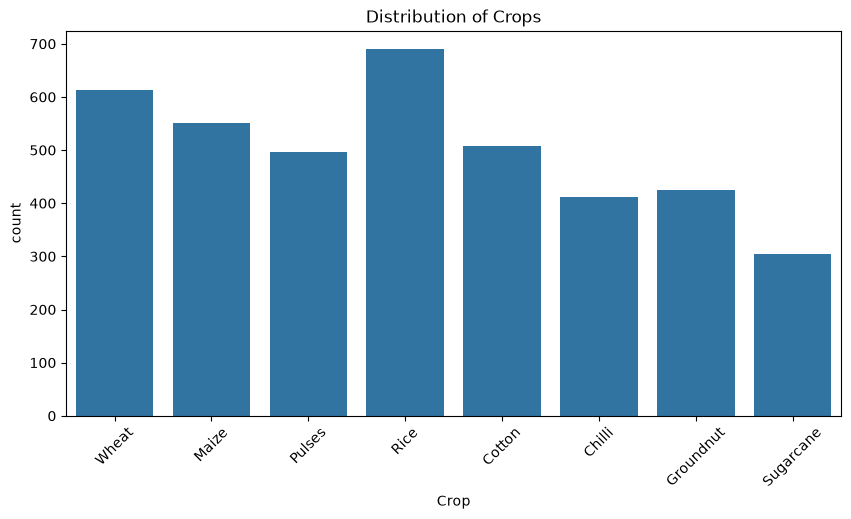

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Crop distribution
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='Crop')
plt.title('Distribution of Crops')
plt.xticks(rotation=45)
plt.show()

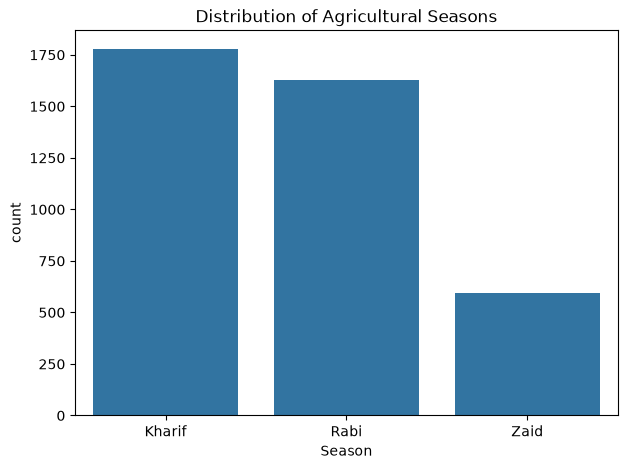

In [ ]:
# 2. Season distribution
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='Season')
plt.title('Distribution of Agricultural Seasons')
plt.show()

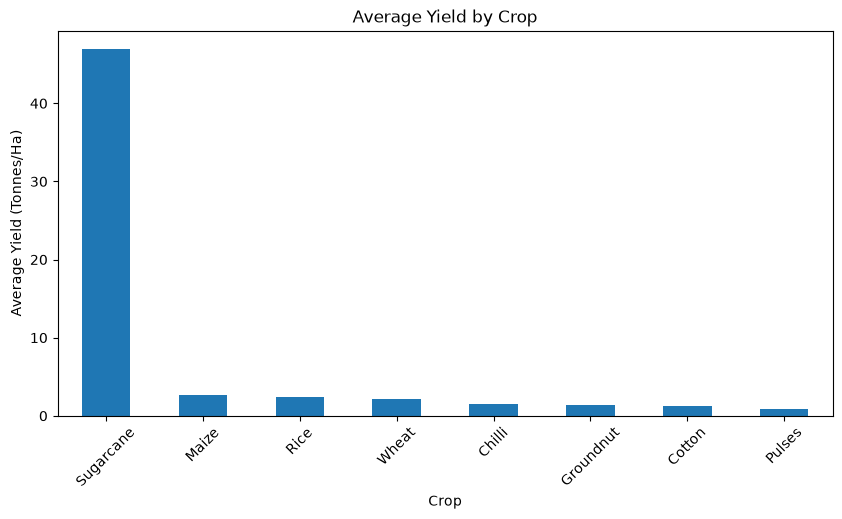

In [ ]:
# 3. Average yield for each crop
crop_yield = df.groupby('Crop')['Yield_Tonnes_Ha'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
crop_yield.plot(kind='bar')
plt.title('Average Yield by Crop')
plt.xlabel('Crop')
plt.ylabel('Average Yield (Tonnes/Ha)')
plt.xticks(rotation=45)
plt.show()

Season
Kharif    5.643973
Rabi      5.080498
Zaid      4.665942
Name: Yield_Tonnes_Ha, dtype: float64


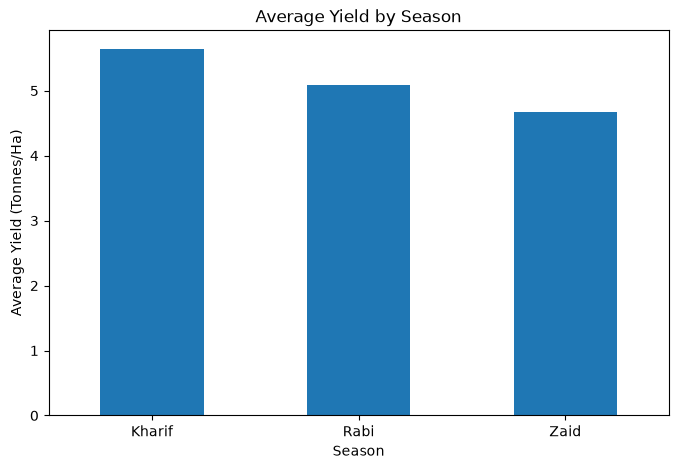

In [ ]:
# Average yield by season

season_yield = df.groupby('Season')['Yield_Tonnes_Ha'].mean().sort_values(ascending=False)

print(season_yield)

plt.figure(figsize=(8, 5))
season_yield.plot(kind='bar')

plt.title('Average Yield by Season')
plt.xlabel('Season')
plt.ylabel('Average Yield (Tonnes/Ha)')
plt.xticks(rotation=0)
plt.show()

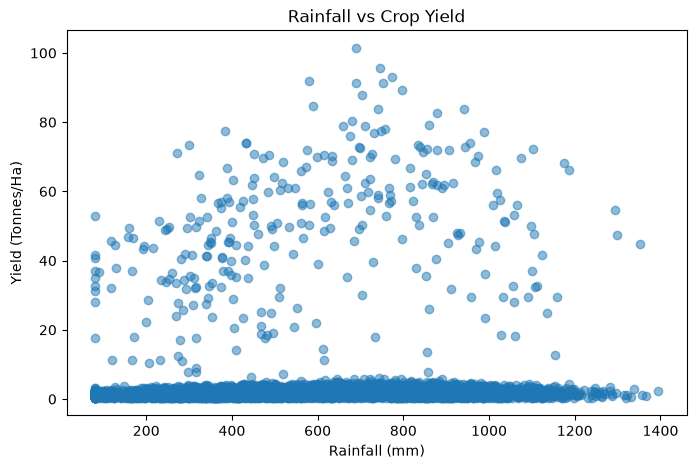

In [ ]:
plt.figure(figsize=(8, 5))

plt.scatter(df['Rainfall_mm'], df['Yield_Tonnes_Ha'], alpha=0.5)

plt.title('Rainfall vs Crop Yield')
plt.xlabel('Rainfall (mm)')
plt.ylabel('Yield (Tonnes/Ha)')

plt.show()

Average Yield by Season:
Season
Kharif    5.643973
Rabi      5.080498
Zaid      4.665942
Name: Yield_Tonnes_Ha, dtype: float64


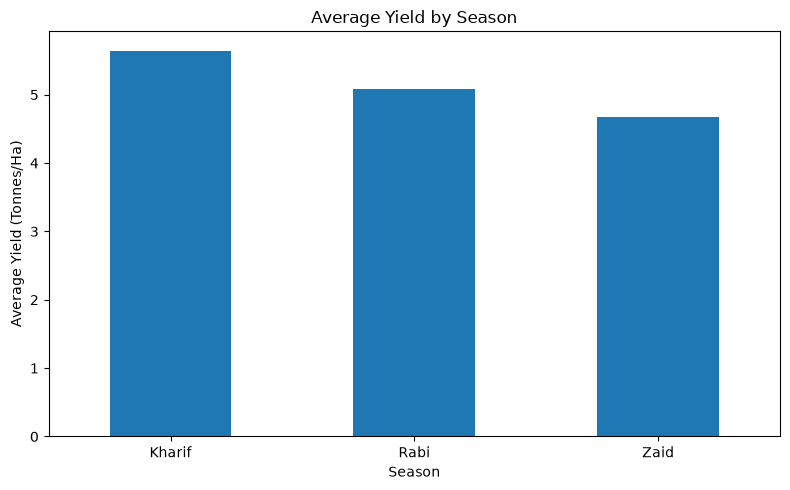

In [ ]:
# Average yield by season

season_yield = df.groupby('Season')['Yield_Tonnes_Ha'].mean().sort_values(ascending=False)

print("Average Yield by Season:")
print(season_yield)

# Plot
plt.figure(figsize=(8, 5))
season_yield.plot(kind='bar')

plt.title('Average Yield by Season')
plt.xlabel('Season')
plt.ylabel('Average Yield (Tonnes/Ha)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

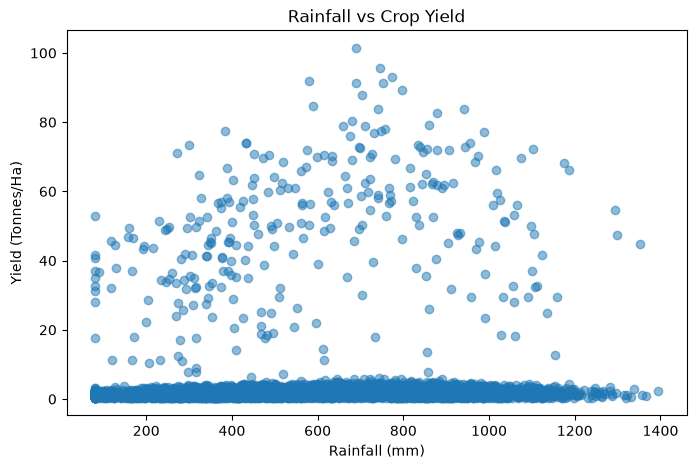

In [ ]:
plt.figure(figsize=(8,5))

plt.scatter(df['Rainfall_mm'], df['Yield_Tonnes_Ha'], alpha=0.5)

plt.title('Rainfall vs Crop Yield')
plt.xlabel('Rainfall (mm)')
plt.ylabel('Yield (Tonnes/Ha)')

plt.show()

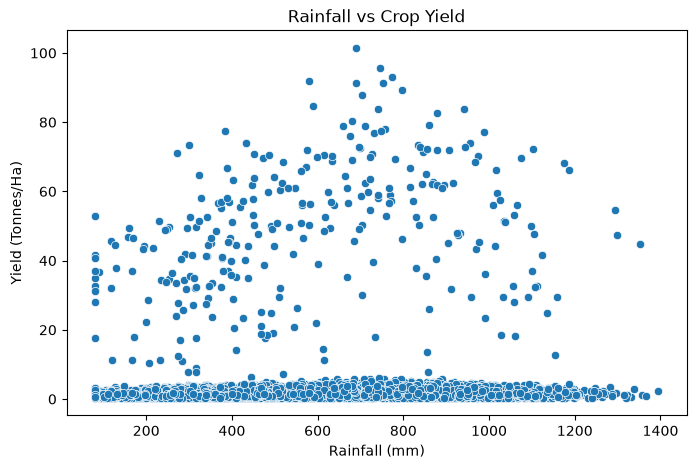

In [ ]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x='Rainfall_mm',
    y='Yield_Tonnes_Ha'
)

plt.title('Rainfall vs Crop Yield')
plt.xlabel('Rainfall (mm)')
plt.ylabel('Yield (Tonnes/Ha)')
plt.show()

In [ ]:
# Select numerical columns
numeric_df = df.select_dtypes(include='number')

# Calculate correlations
correlation = numeric_df.corr()

# Display correlation with Yield
yield_correlation = correlation['Yield_Tonnes_Ha'].sort_values(ascending=False)

print("Correlation with Crop Yield:")
print(yield_correlation)

Correlation with Crop Yield:
Yield_Tonnes_Ha                  1.000000
Water_Efficiency_t_per_1000m3    0.915438
Production_Tonnes                0.885171
Profit_INR                       0.489822
Revenue_INR                      0.433648
Water_Used_m3                    0.388653
Nitrogen_kg_ha                   0.053867
Phosphorus_kg_ha                 0.047821
Rainfall_mm                      0.030853
Total_Cost_INR                   0.030814
Farm_Area_Hectares               0.030188
Disease_Pest_Risk_pct            0.013490
Humidity_pct                     0.011277
Soil_Moisture_pct                0.010210
Avg_Temperature_C                0.009349
Potassium_kg_ha                  0.003836
Fertilizer_kg_ha                 0.000562
Seed_Quality_Score              -0.006737
Pesticide_Litre_ha              -0.007650
Sunlight_Hours_Day              -0.015362
Soil_pH                         -0.020664
Market_Price_INR_Tonne          -0.384307
Name: Yield_Tonnes_Ha, dtype: float64


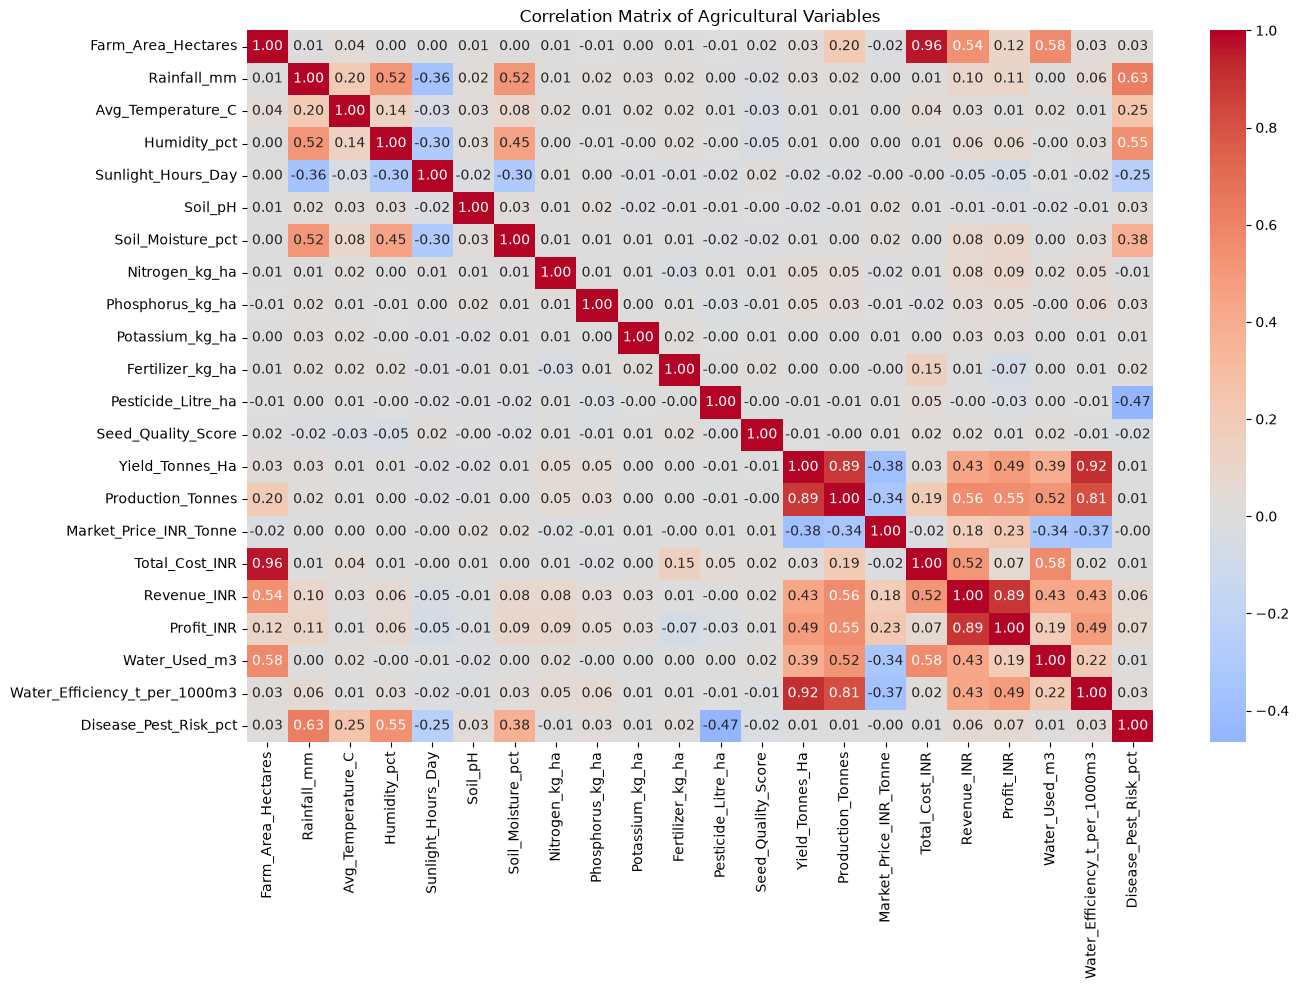

In [ ]:
plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.title('Correlation Matrix of Agricultural Variables')
plt.tight_layout()
plt.show()

Average Rainfall by Season:
Season
Kharif    852.084205
Rabi      436.000124
Zaid      299.421784
Name: Rainfall_mm, dtype: float64


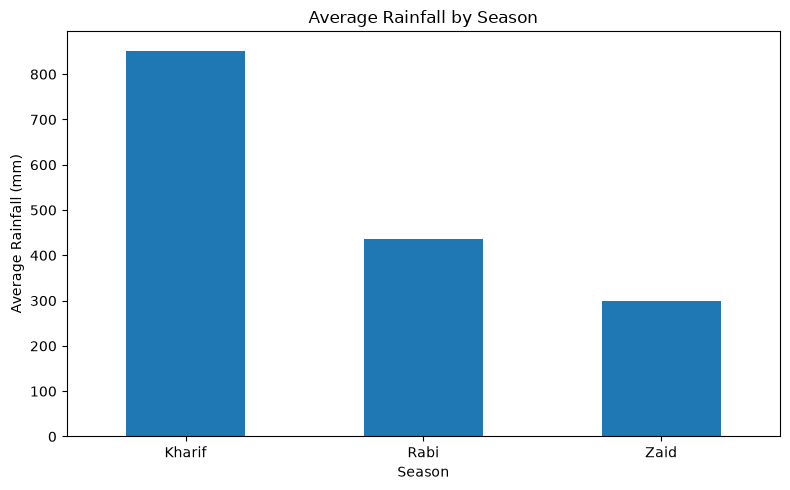

In [ ]:
# Compare average rainfall across seasons

season_environment = df.groupby('Season')['Rainfall_mm'].mean().sort_values(ascending=False)

print("Average Rainfall by Season:")
print(season_environment)

plt.figure(figsize=(8, 5))
season_environment.plot(kind='bar')

plt.title('Average Rainfall by Season')
plt.xlabel('Season')
plt.ylabel('Average Rainfall (mm)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Average Production by Season:
Season
Kharif    46.311192
Rabi      41.486712
Zaid      38.886111
Name: Production_Tonnes, dtype: float64


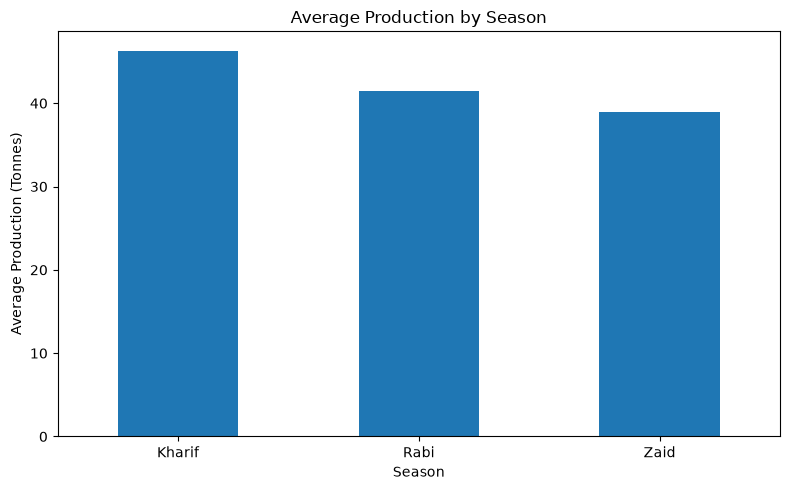

In [ ]:
# Compare average production across seasons

season_production = df.groupby('Season')['Production_Tonnes'].mean().sort_values(ascending=False)

print("Average Production by Season:")
print(season_production)

plt.figure(figsize=(8, 5))
season_production.plot(kind='bar')

plt.title('Average Production by Season')
plt.xlabel('Season')
plt.ylabel('Average Production (Tonnes)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Average Revenue by Season:
Season
Kharif    710719.055649
Rabi      601526.048556
Zaid      519171.904040
Name: Revenue_INR, dtype: float64


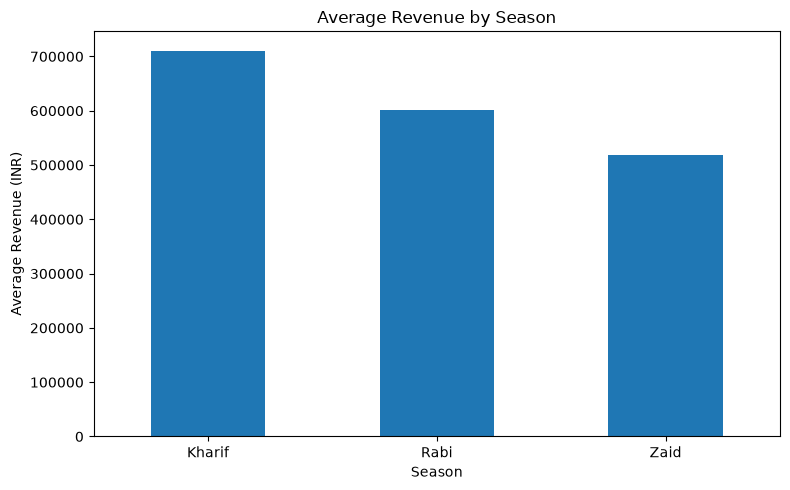

In [ ]:
# Compare average revenue across seasons

season_revenue = df.groupby('Season')['Revenue_INR'].mean().sort_values(ascending=False)

print("Average Revenue by Season:")
print(season_revenue)

plt.figure(figsize=(8, 5))
season_revenue.plot(kind='bar')

plt.title('Average Revenue by Season')
plt.xlabel('Season')
plt.ylabel('Average Revenue (INR)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
from scipy.stats import f_oneway

# Create yield groups for each season
season_groups = [
    group['Yield_Tonnes_Ha'].dropna()
    for season, group in df.groupby('Season')
]

# Perform one-way ANOVA
anova_result = f_oneway(*season_groups)

print("ANOVA Test Result")
print("F-statistic:", anova_result.statistic)
print("p-value:", anova_result.pvalue)

if anova_result.pvalue < 0.05:
    print("Result: Yield differs significantly across seasons.")
else:
    print("Result: No statistically significant difference in yield across seasons.")

ANOVA Test Result
F-statistic: 1.4579589466621523
p-value: 0.23283549440053075
Result: No statistically significant difference in yield across seasons.


Seasonal Rainfall and Yield Comparison:
        Rainfall_mm  Yield_Tonnes_Ha
Season                              
Kharif   852.084205         5.643973
Rabi     436.000124         5.080498
Zaid     299.421784         4.665942


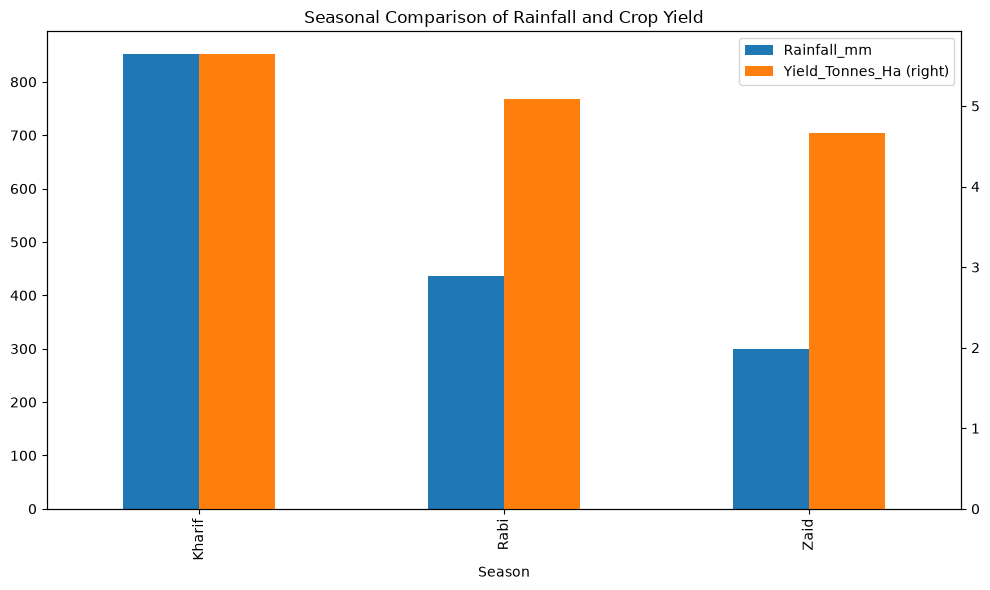

In [ ]:
# Compare rainfall and yield across seasons

season_comparison = df.groupby('Season').agg({
    'Rainfall_mm': 'mean',
    'Yield_Tonnes_Ha': 'mean'
}).sort_values('Yield_Tonnes_Ha', ascending=False)

print("Seasonal Rainfall and Yield Comparison:")
print(season_comparison)

# Visualization
season_comparison.plot(
    kind='bar',
    figsize=(10, 6),
    secondary_y='Yield_Tonnes_Ha'
)

plt.title('Seasonal Comparison of Rainfall and Crop Yield')
plt.xlabel('Season')
plt.tight_layout()
plt.show()

In [ ]:
# Identify the best-performing season

best_yield_season = season_yield.idxmax()
best_production_season = season_production.idxmax()
best_revenue_season = season_revenue.idxmax()

print("Best Season by Yield:", best_yield_season)
print("Best Season by Production:", best_production_season)
print("Best Season by Revenue:", best_revenue_season)

Best Season by Yield: Kharif
Best Season by Production: Kharif
Best Season by Revenue: Kharif


Average Crop Yield Across Seasons:
Season        Kharif       Rabi       Zaid
Crop                                      
Chilli      1.731413   1.461615   1.177742
Cotton      1.372804   1.192915   0.951648
Groundnut   1.483646   1.221445   1.037778
Maize       2.966410   2.614913   2.297590
Pulses      1.036063   0.871887   0.652131
Rice        2.707621   2.333680   1.900490
Sugarcane  53.459120  43.940394  38.423922
Wheat       2.255430   2.058814   1.748588


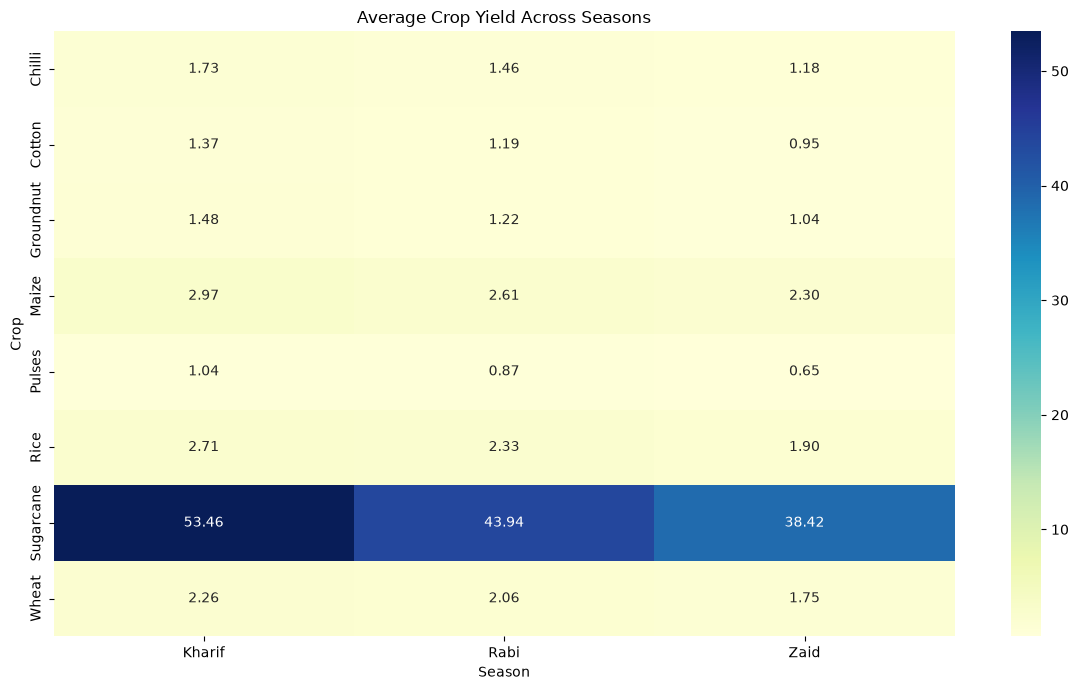

In [ ]:
# Compare average yield of crops across seasons

crop_season_yield = df.pivot_table(
    values='Yield_Tonnes_Ha',
    index='Crop',
    columns='Season',
    aggfunc='mean'
)

print("Average Crop Yield Across Seasons:")
print(crop_season_yield)

# Heatmap
plt.figure(figsize=(12, 7))

sns.heatmap(
    crop_season_yield,
    annot=True,
    fmt='.2f',
    cmap='YlGnBu'
)

plt.title('Average Crop Yield Across Seasons')
plt.xlabel('Season')
plt.ylabel('Crop')
plt.tight_layout()
plt.show()

In [ ]:
# Find highest and lowest crop-season yield combinations

highest_yield = crop_season_yield.stack().idxmax()
lowest_yield = crop_season_yield.stack().idxmin()

highest_value = crop_season_yield.stack().max()
lowest_value = crop_season_yield.stack().min()

print("Highest Yield Combination:")
print("Crop:", highest_yield[0])
print("Season:", highest_yield[1])
print("Yield:", round(highest_value, 2), "Tonnes/Ha")

print("\nLowest Yield Combination:")
print("Crop:", lowest_yield[0])
print("Season:", lowest_yield[1])
print("Yield:", round(lowest_value, 2), "Tonnes/Ha")

Highest Yield Combination:
Crop: Sugarcane
Season: Kharif
Yield: 53.46 Tonnes/Ha

Lowest Yield Combination:
Crop: Pulses
Season: Zaid
Yield: 0.65 Tonnes/Ha


Average Yield by State and Season:
Season            Kharif      Rabi      Zaid
State                                       
Andhra Pradesh  5.693431  3.488069  4.480238
Gujarat         6.338416  5.517245  4.101970
Karnataka       6.523689  4.609655  6.623243
Madhya Pradesh  6.004133  3.800000  5.539194
Maharashtra     5.447014  5.501927  2.285352
Punjab          4.100633  8.609355  5.909610
Tamil Nadu      5.520534  4.555539  4.097746
Telangana       5.568798  4.831649  4.278333


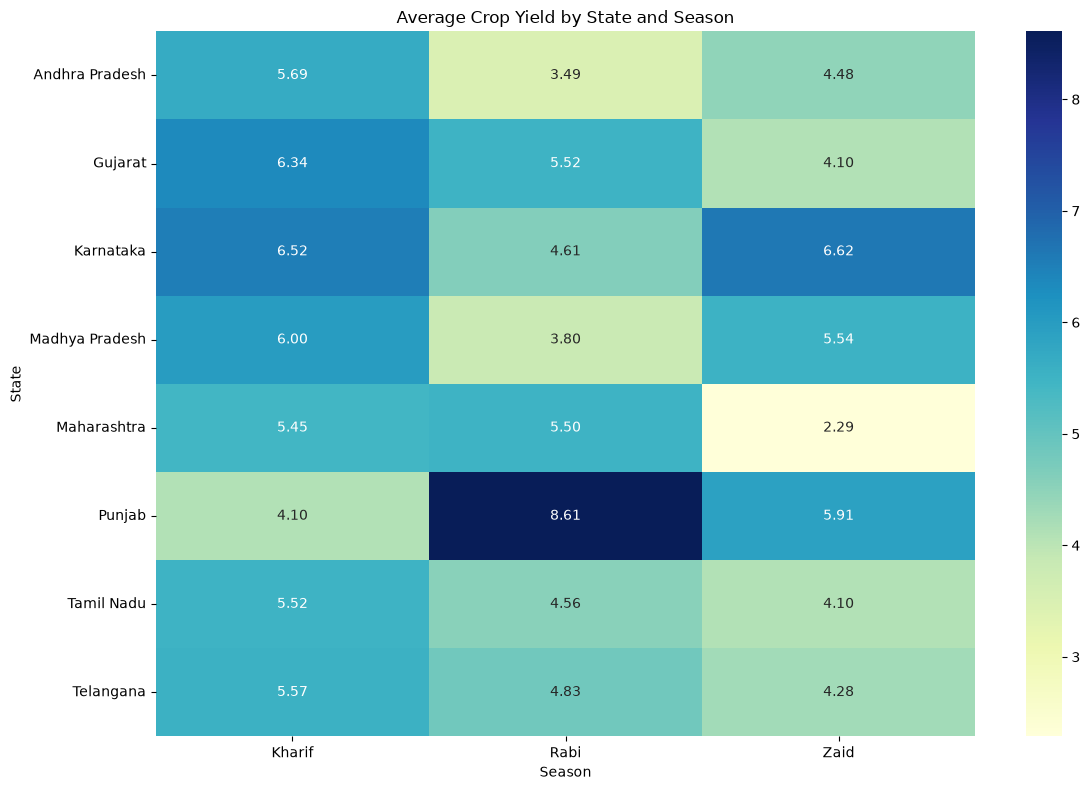

In [ ]:
# Compare average yield by State and Season

state_season_yield = df.pivot_table(
    values='Yield_Tonnes_Ha',
    index='State',
    columns='Season',
    aggfunc='mean'
)

print("Average Yield by State and Season:")
print(state_season_yield)

# Heatmap
plt.figure(figsize=(12, 8))

sns.heatmap(
    state_season_yield,
    annot=True,
    fmt='.2f',
    cmap='YlGnBu'
)

plt.title('Average Crop Yield by State and Season')
plt.xlabel('Season')
plt.ylabel('State')
plt.tight_layout()
plt.show()

Average State-Level Yield by Season:
Season
Kharif    5.649581
Rabi      5.114180
Zaid      4.664461
dtype: float64


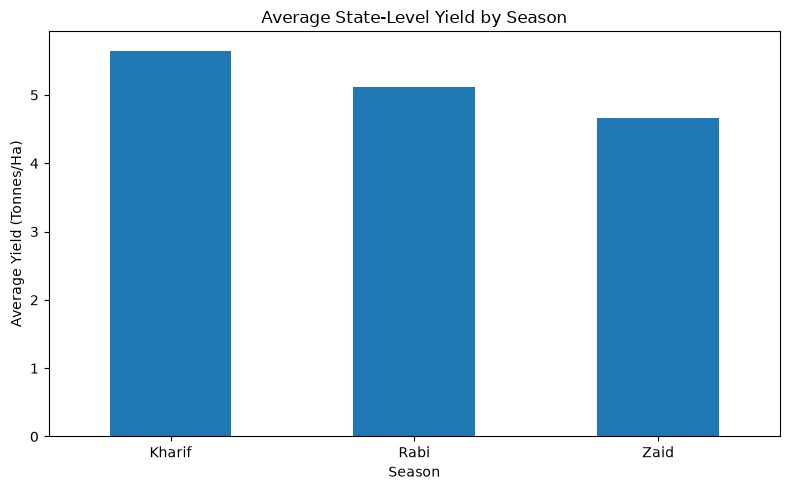

In [ ]:
# Calculate average yield across states for each season

season_state_average = state_season_yield.mean(axis=0).sort_values(ascending=False)

print("Average State-Level Yield by Season:")
print(season_state_average)

plt.figure(figsize=(8, 5))
season_state_average.plot(kind='bar')

plt.title('Average State-Level Yield by Season')
plt.xlabel('Season')
plt.ylabel('Average Yield (Tonnes/Ha)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Average Resources and Environmental Conditions by Season:
        Farm_Area_Hectares  Rainfall_mm
Season                                 
Kharif            7.944924   852.084205
Rabi              7.752207   436.000124
Zaid              8.091246   299.421784


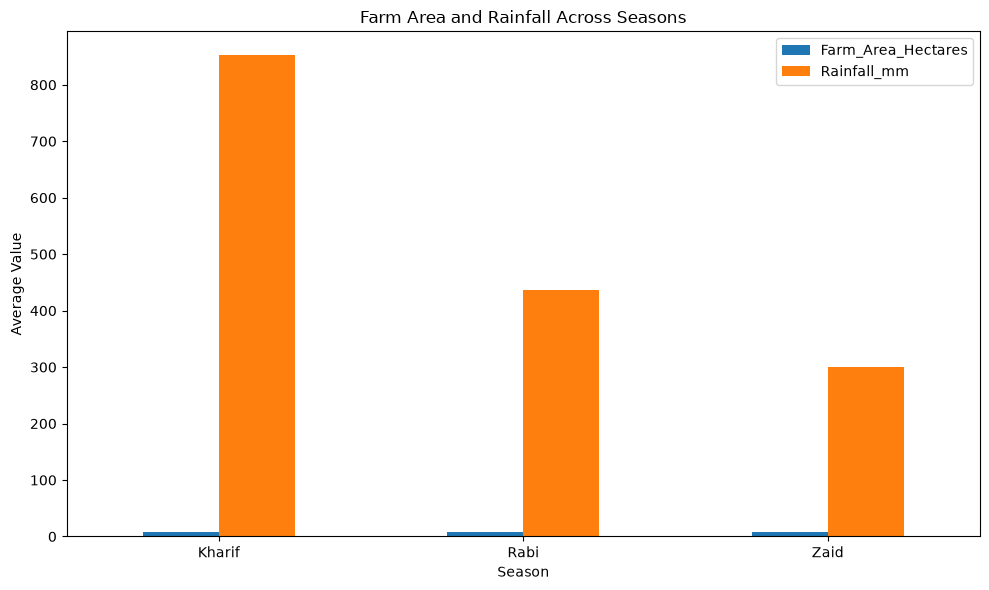

In [ ]:
# Compare farm area and rainfall across seasons

season_resources = df.groupby('Season').agg({
    'Farm_Area_Hectares': 'mean',
    'Rainfall_mm': 'mean'
})

print("Average Resources and Environmental Conditions by Season:")
print(season_resources)

# Visualization
season_resources.plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title('Farm Area and Rainfall Across Seasons')
plt.xlabel('Season')
plt.ylabel('Average Value')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
# Create an overall seasonal performance table

overall_season = df.groupby('Season').agg({
    'Yield_Tonnes_Ha': 'mean',
    'Production_Tonnes': 'mean',
    'Revenue_INR': 'mean'
}).sort_values('Yield_Tonnes_Ha', ascending=False)

print("Overall Seasonal Performance:")
print(overall_season.round(2))

Overall Seasonal Performance:
        Yield_Tonnes_Ha  Production_Tonnes  Revenue_INR
Season                                                 
Kharif             5.64              46.31    710719.06
Rabi               5.08              41.49    601526.05
Zaid               4.67              38.89    519171.90


In [ ]:
# Rank seasons based on agricultural performance

season_ranking = overall_season.copy()

season_ranking['Yield_Rank'] = season_ranking['Yield_Tonnes_Ha'].rank(
    ascending=False
)

season_ranking['Production_Rank'] = season_ranking['Production_Tonnes'].rank(
    ascending=False
)

season_ranking['Revenue_Rank'] = season_ranking['Revenue_INR'].rank(
    ascending=False
)

print("Seasonal Performance Ranking:")
print(season_ranking.round(2))

Seasonal Performance Ranking:
        Yield_Tonnes_Ha  Production_Tonnes  Revenue_INR  Yield_Rank  \
Season                                                                
Kharif             5.64              46.31    710719.06         1.0   
Rabi               5.08              41.49    601526.05         2.0   
Zaid               4.67              38.89    519171.90         3.0   

        Production_Rank  Revenue_Rank  
Season                                 
Kharif              1.0           1.0  
Rabi                2.0           2.0  
Zaid                3.0           3.0  


In [ ]:
# Calculate correlation between rainfall and crop yield

rainfall_yield_corr = df['Rainfall_mm'].corr(df['Yield_Tonnes_Ha'])

print("Correlation between Rainfall and Yield:")
print(round(rainfall_yield_corr, 3))

Correlation between Rainfall and Yield:
0.031


In [ ]:
# Calculate rainfall-yield correlation for each season

season_correlations = df.groupby('Season').apply(
    lambda group: group['Rainfall_mm'].corr(group['Yield_Tonnes_Ha']),
    include_groups=False
)

print("Rainfall-Yield Correlation by Season:")
print(season_correlations.round(3))

Rainfall-Yield Correlation by Season:
Season
Kharif   -0.019
Rabi      0.042
Zaid      0.049
dtype: float64


In [ ]:
# Find numerical variables most strongly related to yield

numeric_df = df.select_dtypes(include='number')

yield_correlations = numeric_df.corr()['Yield_Tonnes_Ha'].drop(
    'Yield_Tonnes_Ha'
).sort_values(ascending=False)

print("Correlation of Numerical Variables with Yield:")
print(yield_correlations.round(3))

Correlation of Numerical Variables with Yield:
Water_Efficiency_t_per_1000m3    0.915
Production_Tonnes                0.885
Profit_INR                       0.490
Revenue_INR                      0.434
Water_Used_m3                    0.389
Nitrogen_kg_ha                   0.054
Phosphorus_kg_ha                 0.048
Rainfall_mm                      0.031
Total_Cost_INR                   0.031
Farm_Area_Hectares               0.030
Disease_Pest_Risk_pct            0.013
Humidity_pct                     0.011
Soil_Moisture_pct                0.010
Avg_Temperature_C                0.009
Potassium_kg_ha                  0.004
Fertilizer_kg_ha                 0.001
Seed_Quality_Score              -0.007
Pesticide_Litre_ha              -0.008
Sunlight_Hours_Day              -0.015
Soil_pH                         -0.021
Market_Price_INR_Tonne          -0.384
Name: Yield_Tonnes_Ha, dtype: float64


In [ ]:
# Final summary of seasonal agricultural performance

final_season_summary = df.groupby('Season').agg(
    Average_Yield=('Yield_Tonnes_Ha', 'mean'),
    Average_Production=('Production_Tonnes', 'mean'),
    Average_Revenue=('Revenue_INR', 'mean'),
    Average_Rainfall=('Rainfall_mm', 'mean'),
    Average_Farm_Area=('Farm_Area_Hectares', 'mean')
).sort_values('Average_Yield', ascending=False)

print("Final Seasonal Agricultural Performance Summary:")
print(final_season_summary.round(2))

Final Seasonal Agricultural Performance Summary:
        Average_Yield  Average_Production  Average_Revenue  Average_Rainfall  \
Season                                                                         
Kharif           5.64               46.31        710719.06            852.08   
Rabi             5.08               41.49        601526.05            436.00   
Zaid             4.67               38.89        519171.90            299.42   

        Average_Farm_Area  
Season                     
Kharif               7.94  
Rabi                 7.75  
Zaid                 8.09  


In [ ]:
# Generate key findings from the analysis

print("===== KEY FINDINGS =====\n")

print("1. Best season based on average yield:")
print(season_yield.idxmax(), 
      "with", round(season_yield.max(), 2), "Tonnes/Ha")

print("\n2. Best season based on average production:")
print(season_production.idxmax(), 
      "with", round(season_production.max(), 2), "Tonnes")

print("\n3. Best season based on average revenue:")
print(season_revenue.idxmax(), 
      "with INR", round(season_revenue.max(), 2))

print("\n4. Season with highest average rainfall:")
print(season_environment.idxmax(), 
      "with", round(season_environment.max(), 2), "mm")

print("\n5. Highest crop-season yield:")
print(highest_yield[0], "during", highest_yield[1],
      "with", round(highest_value, 2), "Tonnes/Ha")

print("\n6. Lowest crop-season yield:")
print(lowest_yield[0], "during", lowest_yield[1],
      "with", round(lowest_value, 2), "Tonnes/Ha")

print("\n7. Overall rainfall-yield correlation:")
print(round(rainfall_yield_corr, 3))

print("\n8. ANOVA p-value for seasonal yield differences:")
print(round(anova_result.pvalue, 5))

===== KEY FINDINGS =====

1. Best season based on average yield:
Kharif with 5.64 Tonnes/Ha

2. Best season based on average production:
Kharif with 46.31 Tonnes

3. Best season based on average revenue:
Kharif with INR 710719.06

4. Season with highest average rainfall:
Kharif with 852.08 mm

5. Highest crop-season yield:
Sugarcane during Kharif with 53.46 Tonnes/Ha

6. Lowest crop-season yield:
Pulses during Zaid with 0.65 Tonnes/Ha

7. Overall rainfall-yield correlation:
0.031

8. ANOVA p-value for seasonal yield differences:
0.23284


## Key Findings and Interpretation

Based on the analysis of seasonal agricultural performance:

1. Agricultural performance varies across seasons, as observed from differences in average yield, production, and revenue.

2. Seasonal rainfall levels vary across the dataset, indicating differences in environmental conditions between seasons.

3. Crop performance is not uniform across seasons. The crop-season analysis shows that certain crops achieve higher yields in particular seasons.

4. Regional analysis shows variations in yield across states and seasons, indicating that seasonal performance may differ geographically.

5. The rainfall-yield correlation indicates the strength and direction of the relationship between rainfall and crop yield.

6. The ANOVA test was used to examine whether the differences in average crop yield across seasons are statistically significant.

7. Economic performance also varies across seasons, as shown by differences in average revenue.

8. The analysis identifies both high-performing and low-performing crop-season combinations, which can be considered important seasonal patterns for agricultural planning.

Overall, the results demonstrate that seasonal conditions, crop selection, regional factors, and environmental conditions are associated with variations in agricultural performance.

## Conclusion

The Seasonal Agriculture Performance Analysis provides insights into how agricultural performance varies across different seasons, crops, and regions.

The analysis compared seasonal yield, production, revenue, rainfall, and farm area. It also examined crop performance across seasons and regional variations across states.

The correlation analysis was used to investigate the relationship between environmental conditions and crop yield, while ANOVA was applied to examine whether seasonal differences in yield were statistically significant.

The results indicate that agricultural performance is influenced by variations in seasonal conditions and that crop and regional performance is not uniform across all seasons.

Overall, the findings can help identify better-performing crop-season combinations and support evidence-based seasonal agricultural planning.

## Data-Driven Recommendations

Based on the findings from the seasonal agricultural analysis, the following recommendations can be made:

1. **Prefer better-performing seasons:** Farmers can prioritize seasons that show higher average yield, production, and revenue in the dataset.

2. **Select crops according to seasonal performance:** Crop selection should consider the crop-season combinations that demonstrate higher yields.

3. **Consider rainfall conditions:** Seasonal rainfall patterns should be considered when planning agricultural activities because rainfall and yield show a measurable relationship in the dataset.

4. **Use regional information for planning:** Since yield varies across states and seasons, agricultural planning should consider regional differences rather than applying the same strategy to every region.

5. **Optimize resource planning:** Differences in farm area and environmental conditions across seasons can be considered when planning the allocation and use of agricultural resources.

6. **Focus on unusual patterns:** Very high- or low-performing crop-season combinations should be investigated further to understand the factors responsible for their performance.

7. **Use data for seasonal decision-making:** Historical seasonal performance data can support decisions about crop selection, resource allocation, and agricultural planning.

# Seasonal Agriculture Performance Analysis

## Project Overview

This project analyzes agricultural performance across different seasons, crops, and regions.

The analysis focuses on:
- Seasonal variations in crop yield and production
- Seasonal rainfall and environmental conditions
- Economic outcomes such as revenue
- Crop performance across different seasons
- Regional variations in agricultural performance
- Relationships between environmental conditions and crop yield
- Statistical differences between seasons
- Identification of unusual and significant patterns

The objective is to derive evidence-based insights that can support better seasonal agricultural planning.